
# Bagging and Boosting Model Evaluation
This notebook evaluates Bagging (Random Forest) and Boosting (XGBoost) models on the Airbnb listings and past rates datasets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# import warnings
# warnings.filterwarnings("ignore")

In [4]:
# Load datasets
print("Loading listings.csv...")
listings = pd.read_csv("listings.csv", on_bad_lines='skip', low_memory=False)
print("Loading past_rates.csv...")
past_rates = pd.read_csv("past_rates.csv", on_bad_lines='skip', low_memory=False)

# Coerce listing_id to numeric to avoid merge errors
listings['listing_id'] = pd.to_numeric(listings['listing_id'], errors='coerce')
past_rates['listing_id'] = pd.to_numeric(past_rates['listing_id'], errors='coerce')

# Drop rows where listing_id is NaN
listings = listings.dropna(subset=['listing_id'])
past_rates = past_rates.dropna(subset=['listing_id'])

print(f"Listings shape: {listings.shape}")
print(f"Past rates shape: {past_rates.shape}")

Loading listings.csv...
Loading past_rates.csv...
Listings shape: (29056, 61)
Past rates shape: (341367, 17)


In [5]:
# Merge datasets on listing_id
df = pd.merge(past_rates, listings, on="listing_id", how="inner", suffixes=("_past", "_listing"))

print("Merged DataFrame shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Merged DataFrame shape: (336907, 77)
Columns: ['listing_id', 'date', 'vacant_days', 'reserved_days', 'occupancy', 'revenue', 'rate_avg', 'booked_rate_avg', 'booking_lead_time_avg', 'length_of_stay_avg', 'min_nights_avg', 'native_booked_rate_avg', 'native_rate_avg', 'native_revenue', 'country_past', 'state_past', 'city_past', 'listing_type', 'room_type', 'cover_photo_url', 'photos_count', 'host_id', 'superhost', 'latitude', 'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'registration', 'amenities', 'instant_book', 'professional_management', 'min_nights', 'cancellation_policy', 'currency', 'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar', 'ttm_adjusted_revpar_native', 'ttm_re

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,booked_rate_avg,booking_lead_time_avg,length_of_stay_avg,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country_listing,state_listing,city_listing
0,3891274,2025-02-01,28,0,0.000,0.0,97.2,NaN,NaN,NaN,...,84026.0,0.0,0.0,8,0,82,90,Indonesia,Bali,Seminyak
1,3891274,2025-03-01,15,16,0.516,1544.0,94.8,96.5,87.0,9.0,...,84026.0,0.0,0.0,8,0,82,90,Indonesia,Bali,Seminyak
2,3891274,2025-04-01,21,9,0.300,808.0,89.2,89.8,173.0,2.0,...,84026.0,0.0,0.0,8,0,82,90,Indonesia,Bali,Seminyak
3,3891274,2025-05-01,19,12,0.387,1076.0,89.2,89.7,153.0,13.0,...,84026.0,0.0,0.0,8,0,82,90,Indonesia,Bali,Seminyak
4,3891274,2025-06-01,24,6,0.200,519.0,86.5,86.5,1.0,5.0,...,84026.0,0.0,0.0,8,0,82,90,Indonesia,Bali,Seminyak


In [6]:
# Select relevant features and target variable
# Target is 'occupancy' from past_rates. If no collision, it stays 'occupancy'.
target = "occupancy" if "occupancy" in df.columns else "occupancy_past"
features = [
    "room_type", "guests", "bedrooms", "beds", "baths", 
    "min_nights_listing", "rating_overall", "photos_count", 
    "listing_type", "instant_book", "superhost"
]

# Fix min_nights if it got a suffix due to collision (listings has min_nights, past_rates has min_nights_avg)
if "min_nights" not in df.columns and "min_nights_listing" not in df.columns:
    # Check what we have
    potential_min_nights = [c for c in df.columns if "min_nights" in c]
    print("Potential min_nights columns:", potential_min_nights)

# Adjust features list based on actual columns
actual_features = []
for f in features:
    if f in df.columns:
        actual_features.append(f)
    elif f + "_listing" in df.columns:
        actual_features.append(f + "_listing")
    elif f.replace("_listing", "") in df.columns:
        actual_features.append(f.replace("_listing", ""))

print("Using features:", actual_features)
print("Using target:", target)

# Ensure features exist and handle missing values
df = df[actual_features + [target]].copy()
df = df.dropna(subset=[target])

# Convert to numeric where possible
numeric_cols = [f for f in actual_features if f not in ["room_type", "listing_type", "instant_book", "superhost"]]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
categorical_cols = [f for f in actual_features if f in ["room_type", "listing_type", "instant_book", "superhost"]]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Label Encode categorical features
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Data preprocessed. Final shape:", df.shape)
df.head()

Using features: ['room_type', 'guests', 'bedrooms', 'beds', 'baths', 'min_nights', 'rating_overall', 'photos_count', 'listing_type', 'instant_book', 'superhost']
Using target: occupancy
Data preprocessed. Final shape: (336907, 12)


,room_type,guests,bedrooms,beds,baths,min_nights,rating_overall,photos_count,listing_type,instant_book,superhost,occupancy
0,2,2.0,1.0,1.0,1.0,1.0,4.25,20.0,82,0,0,0.000
1,2,2.0,1.0,1.0,1.0,1.0,4.25,20.0,82,0,0,0.516
2,2,2.0,1.0,1.0,1.0,1.0,4.25,20.0,82,0,0,0.300
3,2,2.0,1.0,1.0,1.0,1.0,4.25,20.0,82,0,0,0.387
4,2,2.0,1.0,1.0,1.0,1.0,4.25,20.0,82,0,0,0.200


In [7]:
# Split into X and y
# Re-define actual_features in this scope if needed, but it's already in the same notebook
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (269525, 11)
Testing set size: (67382, 11)


In [8]:
# Bagging Model: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Training Complete.")

Random Forest Training Complete.


In [9]:
# Boosting Model: XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost Training Complete.")

XGBoost Training Complete.


In [10]:
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Performance ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R2 Score: {r2:.4f}")
    return mae, mse, r2

rf_metrics = evaluate_model(y_test, rf_preds, "Random Forest (Bagging)")
print()
xgb_metrics = evaluate_model(y_test, xgb_preds, "XGBoost (Boosting)")

--- Random Forest (Bagging) Performance ---
MAE: 0.1737
MSE: 0.0556
R2 Score: 0.4380

--- XGBoost (Boosting) Performance ---
MAE: 0.2342
MSE: 0.0812
R2 Score: 0.1794


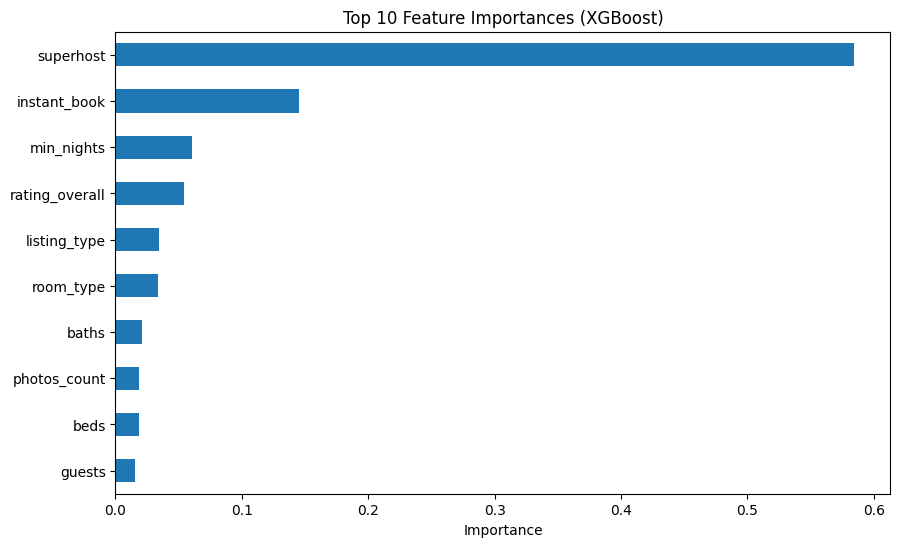

In [11]:
# Visualize feature importance for XGBoost
importances = xgb_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', title='Top 10 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.show()